In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
from tqdm import tqdm
import sys
sys.path.insert(0, "../src/")
from FwdNeuron import *
from DeepEligNeuron import *
from Network import *
from inputFuc import *
from utils import *
from plotting import *
from utilsMNIST import *

In [2]:
def extract_kernel(model, n_steps, layer_idx):
    model.reset()
    impulse = torch.zeros(1, n_steps, 1)
    impulse[0] += 1
    kernel_record = []
    for t in range(n_steps):
        r = impulse[:, t]
        for l in model.layers[:layer_idx]:
            r,u = l.step(r)
        kernel_record.append(u.detach().clone())

    return torch.vstack(kernel_record)

# MNIST-1D

Templates for the MNIST-1D dataset:


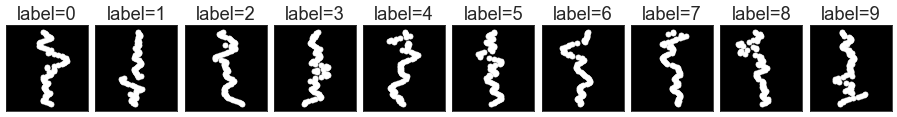

In [3]:
from mnist1d.data import make_dataset, get_dataset_args, get_templates
from mnist1d.utils import from_pickle, to_pickle, ObjectView, set_seed, plot_signals
###TODO padding###
data_config = default_data_config
general_config = default_general_config
train_config = default_train_config
model_config = default_model_config

data = make_dataset(ObjectView(data_config))

templates = get_templates()
print("Templates for the MNIST-1D dataset:")
x = templates['x']
t = templates['t']
y = templates['y']
fig = plot_signals(x, t, labels=y, args=ObjectView(data_config),
                   ratio=1.33, dark_mode=True, do_transform=True)

In [4]:
print(data.keys())
x, y = torch.tensor(data['x'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y'])
x_test, y_test = torch.tensor(data['x_test'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y_test'])
x.shape, y.shape

dict_keys(['x', 'x_test', 'y', 'y_test', 't', 'templates'])


(torch.Size([4000, 72, 1]), torch.Size([4000]))

In [5]:
#### With P learning ###
dt = general_config["dt"]
n_steps = data_config["final_seq_length"]
answer_period = 24

# init both teacher and student net
batch = train_config["batch_size"]

model = buildMNISTNet(model_config, general_config)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=4e-4#train_config["learning_rate"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=2
)

kernel_record = extract_kernel(model, n_steps=int(1.5*data_config["final_seq_length"]), layer_idx=model_config["num_LP_layers"])
kernel_record_pre = kernel_record.numpy().T

In [6]:
error_record, mismatch_record = [], []
Cum_errors = 0.5
num_epochs = 50

with torch.no_grad():
    for epoch in range(num_epochs):
        permu = np.random.permutation(4000).reshape(-1, batch)
        pbar = tqdm(
            permu,
            total=permu.shape[0],
        )
        for idx in pbar:
            total_error = train_batch(model, optimizer, x[idx], y[idx], answer_period)
            Cum_errors = 0.95*Cum_errors + 0.05*total_error
                
        test_acc, test_loss = test(model, x_test, y_test, answer_period)
        scheduler.step(test_loss)
        error_record.append(Cum_errors)   
        print("Train loss: %3f, Test acc: %2f, Epoch: %d"%(Cum_errors, test_acc, epoch+1))
                
print('finished')

100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:12<00:00,  8.03it/s]


Train loss: 0.167581, Test acc: 0.356000, Epoch: 1


100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:12<00:00,  7.92it/s]


Train loss: 0.158708, Test acc: 0.377000, Epoch: 2


100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:12<00:00,  8.00it/s]


...

Train loss: 0.104181, Test acc: 0.547000, Epoch: 48


100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:12<00:00,  7.86it/s]


Train loss: 0.109098, Test acc: 0.544000, Epoch: 49


100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:12<00:00,  7.86it/s]


Train loss: 0.105696, Test acc: 0.549000, Epoch: 50
finished


In [12]:
for l in model.layers[:3]:
    print(l.TauDE, l.decay_de)
    print(l.elig.shape, torch.abs(l.elig).mean())
    print(torch.abs(l.W_in).mean(), torch.abs(l.bias).mean())
    print()

tensor([1.3000, 8.2000, 1.2000, 8.1000, 1.1000, 8.0000]) tensor([0.6154, 0.9390, 0.5833, 0.9383, 0.5455, 0.9375])
torch.Size([1, 6, 60, 1]) tensor(0.)
tensor(1.1637, grad_fn=<MeanBackward0>) tensor(0.0805, grad_fn=<MeanBackward0>)

tensor([1.3000, 8.2000, 1.2000, 8.1000]) tensor([0.6154, 0.9390, 0.5833, 0.9383])
torch.Size([1, 4, 60, 60]) tensor(0.)
tensor(0.1699, grad_fn=<MeanBackward0>) tensor(0.0759, grad_fn=<MeanBackward0>)

tensor([1.3000, 8.2000]) tensor([0.6154, 0.9390])
torch.Size([1, 2, 60, 60]) tensor(0.)
tensor(0.1736, grad_fn=<MeanBackward0>) tensor(0.0620, grad_fn=<MeanBackward0>)



In [14]:
for l in model.layers[:3]:
    print(l.TauDE, l.decay_de)
    print(l.elig.shape, torch.abs(l.elig).mean())
    print(torch.abs(l.W_in).mean(), torch.abs(l.bias).mean())
    print()

tensor([1.3000, 8.2000, 1.2000, 8.1000, 1.1000, 8.0000]) tensor([0.6154, 0.9390, 0.5833, 0.9383, 0.5455, 0.9375])
torch.Size([1, 6, 60, 1]) tensor(0.)
tensor(0.9933, grad_fn=<MeanBackward0>) tensor(0.0657, grad_fn=<MeanBackward0>)

tensor([1.3000, 8.2000, 1.2000, 8.1000]) tensor([0.6154, 0.9390, 0.5833, 0.9383])
torch.Size([1, 4, 60, 60]) tensor(0.)
tensor(0.2104, grad_fn=<MeanBackward0>) tensor(0.0723, grad_fn=<MeanBackward0>)

tensor([1.3000, 8.2000]) tensor([0.6154, 0.9390])
torch.Size([1, 2, 60, 60]) tensor(0.)
tensor(0.2430, grad_fn=<MeanBackward0>) tensor(0.0817, grad_fn=<MeanBackward0>)



In [11]:
#TEST
acc, loss = test(model, x_test, y_test, 1.5*answer_period)
print('Test Accuracy: ', acc, "Test Loss", loss)

Test Accuracy:  0.5049999952316284 Test Loss 0.12194836139678955


In [15]:
kernel_record = extract_kernel(model, n_steps=int(1.5*data_config["final_seq_length"]), layer_idx=model_config["num_LP_layers"])
kernel_record_post = kernel_record.numpy().T

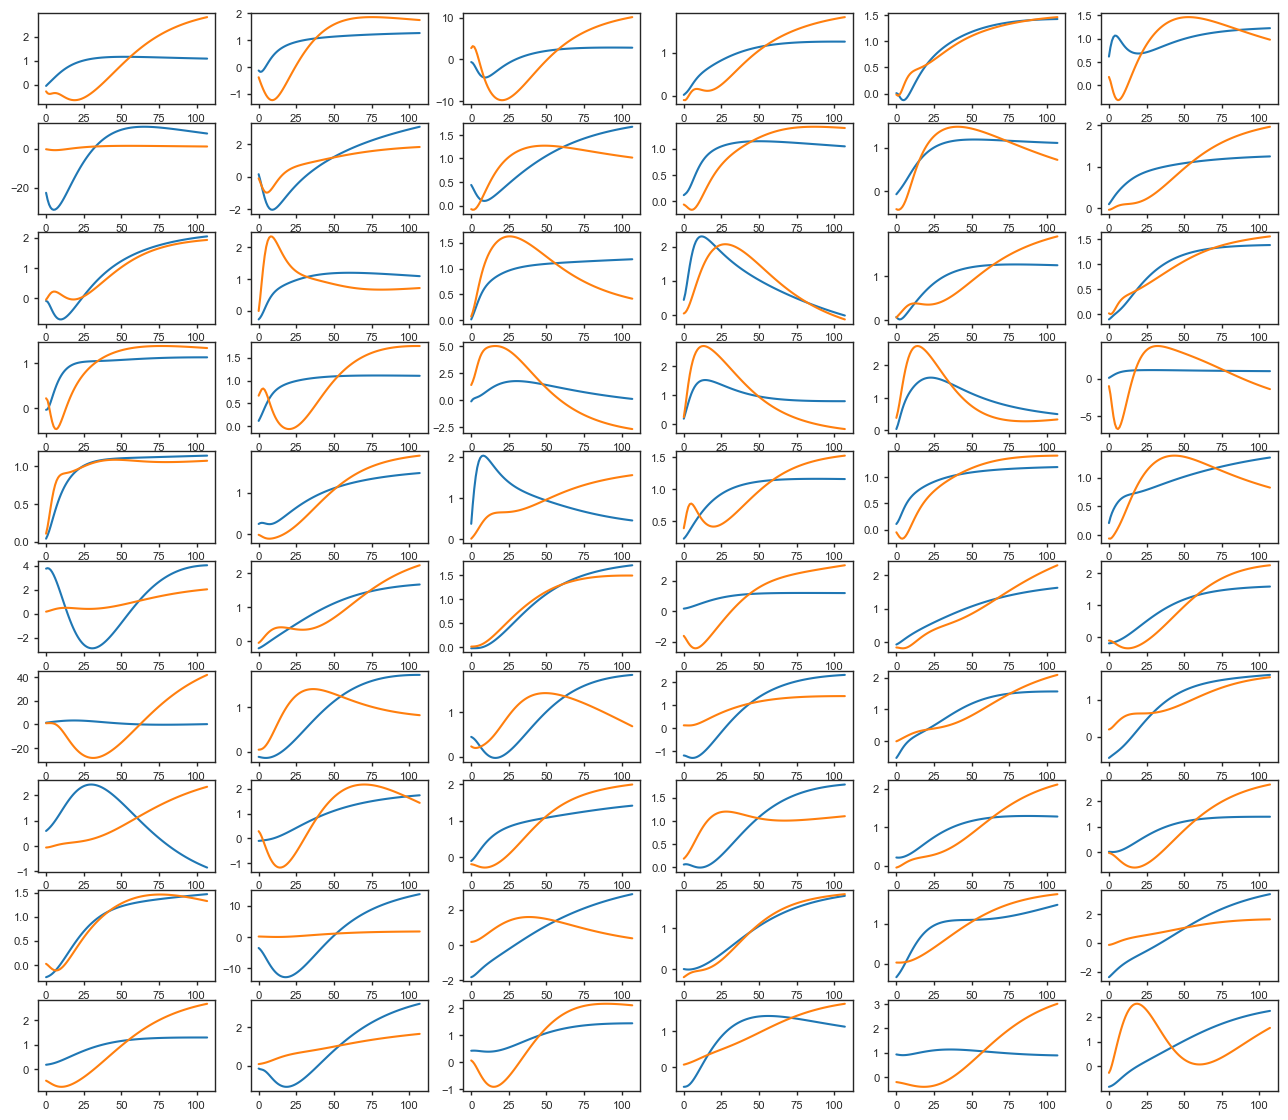

In [17]:
kernel_record_pre_norm = kernel_record_pre / kernel_record_pre.mean(axis=1)[:, None]
kernel_record_post_norm = kernel_record_post / kernel_record_post.mean(axis=1)[:, None]
fig, axs = plt.subplots(10, 6, figsize=(16, 14))
for i, ax in enumerate(axs.ravel()):
    ax.plot(kernel_record_pre_norm[i])
    ax.plot(kernel_record_post_norm[i])

In [24]:
model.layers[0].W_in.min()

tensor(-5.9174, grad_fn=<MinBackward1>)